# **Homework 1**

*Artificial Intelligence II - Fall Semester 2021*

*Deep Learning for Natural Language Processing*


---



Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### **Imports**

Import needed libraries and download packages "punkt" and "popular"

In [2]:
import pandas as pd
import numpy as np
from string import digits
import re
import nltk

nltk.download('punkt')
nltk.download('popular')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import matplotlib.pyplot as plt

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Package cmudict is already up-to-date!
[nltk_data]    | Downloading package gazetteers to /root/nltk_data...
[nltk_data]    |   Package gazetteers is already up-to-date!
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    |   Package genesis is already up-to-date!
[nltk_data]    | Downloading package gutenberg to /root/nltk_data...
[nltk_data]    |   Package gutenberg is already up-to-date!
[nltk_data]    | Downloading package inaugural to /root/nltk_data...
[nltk_data]    |   Package inaugural is already up-to-date!
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package movie_reviews is already up-to-date!
[nltk_data]    | Downloading 

Read train data from csv file.

In [3]:
df_train = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_train.csv", index_col=[0])
df_train.head()

,tweet,label
0,Sip N Shop Come thru right now #Marjais #Popul...,0
1,I don't know about you but My family and I wil...,1
2,@MSignorile Immunizations should be mandatory....,2
3,President Obama spoke in favor of vaccination ...,0
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0


Read test data from csv file.

In [4]:
df_test = pd.read_csv("/content/drive/MyDrive/University/Vaccine Sentiment Dataset/vs_dev.csv", index_col=[0])
df_test.head()

,tweet,label
0,@user They had a massive surge in with covid d...,1
1,Required vaccines for school: Parents and guar...,0
2,“@KCStar: Two more Johnson County children hav...,0
3,NV can do better. Which states are the best (a...,2
4,Nothing like killing ourselves w/ our own fear...,2


Graphic representation of vaccine sentiment categories

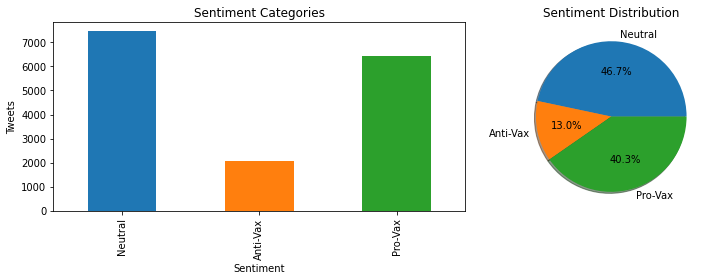

In [5]:
# Bar chart
plt.subplot(1, 2, 1)
bars = ['Neutral', 'Anti-Vax', 'Pro-Vax']
df_train.groupby('label')['tweet'].count().plot.bar(color=['tab:blue', 'tab:orange', 'tab:green'])
plt.grid(False)
plt.title('Sentiment Categories')
plt.xticks(np.arange(3), bars)
plt.ylabel('Tweets')
plt.xlabel('Sentiment')
plt.subplots_adjust(right=1.9)

# Pie Chart
plt.subplot(1, 2, 2)
values = [df_train[df_train['label']==0].shape[0], df_train[df_train['label']==1].shape[0], df_train[df_train['label']==2].shape[0]]
labels = ['Neutral', 'Anti-Vax', 'Pro-Vax']

plt.pie(values, labels=labels, autopct='%1.1f%%', shadow=True)
plt.title('Sentiment Distribution')
plt.tight_layout()
plt.subplots_adjust(right=1.9)
plt.show()

## **Feature Extraction**

Proceed to extract some features.


*   ***len*** = Length of tweet
*   ***n_words*** = Number of words in tweet
*   ***n_stopwords*** = Number of stopwords in tweet

In [6]:
############################################
#######      Feature Extraction      #######
############################################

#for train data
df_train['len'] = (df_train['tweet'].astype(str)).apply(lambda x: len(x))
df_train['n_words'] = (df_train['tweet'].astype(str)).apply(lambda x: len(x.split(" ")))
df_train['n_stopwords'] = df_train['tweet'].apply(lambda x: len([c for c in str(x).lower().split() if c in stopwords.words('english')]))
df_train.head()

,tweet,label,len,n_words,n_stopwords
0,Sip N Shop Come thru right now #Marjais #Popul...,0,108,15,1
1,I don't know about you but My family and I wil...,1,93,18,11
2,@MSignorile Immunizations should be mandatory....,2,140,20,7
3,President Obama spoke in favor of vaccination ...,0,138,21,8
4,"""@myfoxla: Arizona monitoring hundreds for mea...",0,125,16,5


In [7]:
#for test data
df_test['len'] = (df_test['tweet'].astype(str)).apply(lambda x: len(x))
df_test['n_words'] = (df_test['tweet'].astype(str)).apply(lambda x: len(x.split(" ")))
df_test['n_stopwords'] = df_test['tweet'].apply(lambda x: len([c for c in str(x).lower().split() if c in stopwords.words('english')]))
df_test.head()

,tweet,label,len,n_words,n_stopwords
0,@user They had a massive surge in with covid d...,1,196,34,19
1,Required vaccines for school: Parents and guar...,0,131,17,6
2,“@KCStar: Two more Johnson County children hav...,0,89,10,2
3,NV can do better. Which states are the best (a...,2,128,17,7
4,Nothing like killing ourselves w/ our own fear...,2,130,18,6


## **Data Preprocess**



---



###Text Data Cleaning

>For the data cleaning process, the following were included: 
* Remove all whitespaces and newlines 
* Remove all special characters and punctuation
* Replace contractions with full words (despite that they might be removed   later from the stopwords)
* Splitted attached words e.g.  “ForTheWin” =>  “For The Win”
* Lowered all capital letters  
* Removed Numbers from text corpus
* Standarizing sentences

>Both train and test data are preprocessed in the same exact way.

>(reference link: [python-efficient-text-data-cleaning](https://www.geeksforgeeks.org/python-efficient-text-data-cleaning/)

In [8]:
def numbers(x):
  return re.sub(r'[0-9]+', '', x)

def blank_space(x):
  return re.sub('[^A-Za-z0-9]+', ' ', x)

def standarize_sentence(x):
  return ''.join(''.join(word)[:2] for word in x) 

def apostrophe_words(x):
  Apos_dict={"'s":" is","'t":" not","'m":" am","'ll":" will", "'d":" would","'ve":" have","'re":" are", 
             "’s":" is","’t":" not","’m":" am", "’d":" would","’ve":" have","’re":" are", "’ll": "will"} 
  for key,value in Apos_dict.items(): 
    if key in x:
      x =  x.replace(key,value)
      return x
  return x

def split_words(x):
  return " ".join([word for word in re.split("([A-Z][a-z]+[^A-Z]*)",x) if word])

def shallow_cleaning(df):
  remove_digits = str.maketrans('', '', digits)
  df['tweet'] = df['tweet'].apply(lambda x: blank_space(x))
  df['tweet'] = df['tweet'].apply(lambda x: apostrophe_words(x))
  df['tweet'] = df['tweet'].str.strip()
  df['tweet'] = df['tweet'].str.lower()
  df['tweet'] = df['tweet'].apply(lambda x: numbers(x))
  df['tweet'] = df['tweet'].apply(lambda x: split_words(x))
  df['tweet'] = df['tweet'].apply(lambda x: standarize_sentence(x))
  return df

df_train = shallow_cleaning(df_train)
display(df_train)

,tweet,label,len,n_words,n_stopwords
0,sip n shop come thru right now marjais popular...,0,108,15,1
1,i don t know about you but my family and i wil...,1,93,18,11
2,msignorile immunizations should be mandatory p...,2,140,20,7
3,president obama spoke in favor of vaccination ...,0,138,21,8
4,myfoxla arizona monitoring hundreds for measle...,0,125,16,5
...,...,...,...,...,...
15971,salon if u believe the anti vax nutcases cause...,1,135,22,7
15972,how do you feel about parents who don t vaccin...,0,105,11,7
15973,preschoolers tested for measles in simi valle...,0,72,9,2
15974,finance minister budget offers room to procure...,0,103,12,2


In [9]:
df_test = shallow_cleaning(df_test)
display(df_test)

,tweet,label,len,n_words,n_stopwords
0,user they had a massive surge in with covid de...,1,196,34,19
1,required vaccines for school parents and guard...,0,131,17,6
2,kcstar two more johnson county children have m...,0,89,10,2
3,nv can do better which states are the best and...,2,128,17,7
4,nothing like killing ourselves w our own fear ...,2,130,18,6
...,...,...,...,...,...
2277,rt abc number of measles cases reported in cal...,0,140,26,8
2278,evidence points to the idea that measles affec...,0,133,20,8
2279,where s savedyouaclick voxdotcom why you shoul...,2,112,13,5
2280,some of my favorite people have autism if that...,2,133,21,9


## Stemming

To enhance the classification performance we proceeded to stem the data of *Title Content* column. 

Stemming is a Text Normalization (or sometimes called Word Normalization) techniques in the field of Natural Language Processing that are used to prepare text, words, and documents for further processing. Stemming helps us to achieve the root forms (sometimes called synonyms in search context) of inflected (derived) words. Thus, we define as Stem (root) the part of the word to which we add inflectional (changing/deriving) affixes such as (-ed,-ize, -s,-de,mis). So stemming a word or sentence may result in words that are not actual words. Stems are created by removing the suffixes or prefixes used with a word.

For this process we used PorterStemmer for the English language. 

Stemming is applied both on the train and test dataset.

In [10]:
porter = PorterStemmer()

def stemming(df):
  df = df.apply(lambda x: word_tokenize(x))
  df = df.apply(lambda x: [porter.stem(word) for word in x])
  df = df.apply(lambda x: ' '.join(str(word) for word in x))
  return df

df_train['stemmed'] = stemming(df_train['tweet'])

df_train.head()

,tweet,label,len,n_words,n_stopwords,stemmed
0,sip n shop come thru right now marjais popular...,0,108,15,1,sip n shop come thru right now marjai popularn...
1,i don t know about you but my family and i wil...,1,93,18,11,i don t know about you but my famili and i wil...
2,msignorile immunizations should be mandatory p...,2,140,20,7,msignoril immun should be mandatori period in ...
3,president obama spoke in favor of vaccination ...,0,138,21,8,presid obama spoke in favor of vaccin for chil...
4,myfoxla arizona monitoring hundreds for measle...,0,125,16,5,myfoxla arizona monitor hundr for measl link t...


In [11]:
df_test['stemmed'] = stemming(df_test['tweet'])

df_test.head()

,tweet,label,len,n_words,n_stopwords,stemmed
0,user they had a massive surge in with covid de...,1,196,34,19,user they had a massiv surg in with covid deat...
1,required vaccines for school parents and guard...,0,131,17,6,requir vaccin for school parent and guardian o...
2,kcstar two more johnson county children have m...,0,89,10,2,kcstar two more johnson counti children have m...
3,nv can do better which states are the best and...,2,128,17,7,nv can do better which state are the best and ...
4,nothing like killing ourselves w our own fear ...,2,130,18,6,noth like kill ourselv w our own fear mt alyss...


### **Standardization**
Standardization of a dataset is a common requirement for many machine learning estimators: they might behave badly if the individual features do not more or less look like standard normally distributed data (e.g. Gaussian with 0 mean and unit variance).

For instance many elements used in the objective function of a learning algorithm (such as the RBF kernel of Support Vector Machines or the L1 and L2 regularizers of linear models) assume that all features are centered around 0 and have variance in the same order. If a feature has a variance that is orders of magnitude larger that others, it might dominate the objective function and make the estimator unable to learn from other features correctly as expected.

All the features extracted earlier from the dataset corpus, do not necessarily follow the normal distribution curve, which is proved to enhance the algorithms learning process, as explained in the previous paragraphs.

In [12]:
# Standardize stats features
from sklearn.preprocessing import StandardScaler

# question length
num_words =  StandardScaler()
X_train_num_words = num_words.fit_transform(df_train['len'].values.reshape(-1, 1))
X_test_num_words = num_words.transform(df_test['len'].values.reshape(-1, 1))

# number of unique words
num_unique_words =  StandardScaler()
X_train_num_unique_words = num_unique_words.fit_transform(df_train['n_words'].values.reshape(-1, 1))
X_test_num_unique_words = num_unique_words.transform(df_test['n_words'].values.reshape(-1, 1))

# number of stopwords
num_stopwords =  StandardScaler()
X_train_num_stopwords = num_stopwords.fit_transform(df_train['n_stopwords'].values.reshape(-1, 1))
X_test_num_stopwords = num_stopwords.transform(df_test['n_stopwords'].values.reshape(-1, 1))

## **Vectorizers**


---


### TF-IDF

We use the tfidf vectorizer to create the bag of words. TF-IDF stands for Term Frequency-Inverse Document Frequency. The Bag of Words (BoW) model is the simplest form of text representation in numbers. Like the term itself, we can represent a sentence as a bag of words vector (a string of numbers). A simple Bag of Words (like one created with the use of CountVectorizer class), just creates a set of vectors containing the count of word occurrences in the corpus given. On the other hand, the TF-IDF model contains information on the more important words and the less important ones as well. In this case we create a BoW with the default number of  features. 

In [13]:
stop_words = nltk.corpus.stopwords.words('english')

def getBOWTfidf(df, min_df = 100,ngrams = 1,analyzer = 'word'):
  BOW = TfidfVectorizer( ngram_range=(1,ngrams)) #, lowercase=True, stop_words=stopwords.words('english'))
  BOW.fit(df.values.astype('U'))
  print('Tf-idf Vocabulary size is {}'.format(len(BOW.vocabulary_)))
  return BOW

### Count Vectorizer

In [14]:
def getBOWCountVec(df, min_df = 100,ngrams = 1,analyzer = 'word'):
  BOW = CountVectorizer( ngram_range=(1,ngrams)) #, lowercase=True, stop_words=stopwords.words('english'))
  BOW.fit(df.values.astype('U'))
  print('Count Vectorizer Vocabulary size is {}'.format(len(BOW.vocabulary_)))
  return BOW

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_validate
from sklearn.utils import resample, shuffle
from sklearn.metrics import f1_score
from sklearn.metrics import plot_confusion_matrix
import time
import scipy

## **Vaccine Sentiment Classifier**
---

In general for each classification algorithm, the process we follow is the same. 


1.   Create the bag of words for the tweets.
2.   Stack the aforementioned BoWs along with the extracted features from the train or test data respectively, in order to create a single array containing all the information we have available.
3. Initialize the classifier of our choice with its specific parameters. The latter were decided after multiple experiments.
5. Fit train data in the model.
6. Make predictions for the test data.

The above process is repeated k times, each time on a different portion of the data. In every loop this chunk is augmented and always arbitrary, except for the last loop, where the whole dataset is given to the model for trainning. In this experiment k=5.

The process described in the enumeration above, is repeated twice inside every loop, one time for the BoW created with the TF-IDF vectorizer and one for the Count Vectorizer.

###**Logistic Regression**

>Logistic regression is common and is a useful regression method for solving the binary classification problems, not like the problem at hand, where we have three different problem classes. It is one of the most simple and commonly used Machine Learning algorithms for two-class classification. It is easy to implement and can be used as the baseline for any binary classification problem. Its basic fundamental concepts are also constructive in deep learning. Logistic regression describes and estimates the relationship between one dependent binary variable and independent variables.
Some of the properties of Logistic regression are:
*   The dependent variable in logistic regression follows Bernoulli Distribution.
*   Estimation is done through maximum likelihood.
*   No [R Square](https://www.investopedia.com/terms/r/r-squared.asp), Model fitness is calculated through Concordance, [KS-Statistics](https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test).

In [16]:
def logisticRegression(min_df = 100,ngrams = 1,analyzer = 'word',train = df_train, test=df_test, cv=5):
  
  start_time = time.time()

  print('Logistic Regression with Tf-idf')
  print(str(cv)+'-Fold Cross Validation')  
  print("----------------------------------\n")
  
  scores = pd.DataFrame(columns=['F1 Score Train', 'F1 Score Test', 'F1 Score Train CV', 'F1 Score Test CV', 'Sample Size']);

  model_tfidf = LogisticRegression(n_jobs=4,C=0.08, max_iter=700, solver='newton-cg', penalty='l2')
  model_cv = LogisticRegression(n_jobs=4,C=0.002, max_iter=700, solver='newton-cg', penalty='l2')

  for x in range(cv, 0, -1):

    #split in subset
    max_size = len(df_train['label'])
    n_samples = max_size/x
    train_sample, X_train_num_words_sample, X_train_num_unique_words_sample, X_train_num_stopwords_sample,  = shuffle(df_train, X_train_num_words, X_train_num_unique_words, X_train_num_stopwords, n_samples=int(n_samples) , random_state=0)   
    
    BOW = getBOWTfidf(train_sample['stemmed'], min_df=min_df,ngrams = ngrams,analyzer = analyzer)
    train_trans = BOW.transform(train_sample['stemmed'].values.astype('U'))
    test_trans = BOW.transform(test['stemmed'].values.astype('U'))
    
    labels = train_sample['label'].values

    # stack the train feature arrays horizontally (i.e. column wise) 
    # with the bow of the train data to make a single array
    X = scipy.sparse.hstack((
        train_trans,
        X_train_num_words_sample,
        X_train_num_unique_words_sample,
        X_train_num_stopwords_sample,
        
    ))
    y = labels
    
    # stack the test feature arrays horizontally (i.e. column wise) 
    # with the bow of the test data to make a single array
    X_test = scipy.sparse.hstack((
      test_trans,
      X_test_num_words,
      X_test_num_unique_words,
      X_test_num_stopwords,
    ))
    y_test = test['label']

    model_tfidf.fit(X, y)   #fit train data
    Y_train_predict = model_tfidf.predict(X)      #predict for train data
    Y_test_predict = model_tfidf.predict(X_test)  #predict for test data

    BOW = getBOWCountVec(train_sample['stemmed'], min_df=min_df,ngrams = ngrams,analyzer = analyzer)
    train_trans = BOW.transform(train_sample['stemmed'].values.astype('U'))
    test_trans = BOW.transform(test['stemmed'].values.astype('U'))

    X = scipy.sparse.hstack((
      train_trans,
      X_train_num_words_sample,
      X_train_num_unique_words_sample,
      X_train_num_stopwords_sample,
    ))

    X_test = scipy.sparse.hstack((
      test_trans,
      X_test_num_words,
      X_test_num_unique_words,
      X_test_num_stopwords,
    ))

    model_cv.fit(X, y)   #fit train data
    Y_train_predict_cv = model_cv.predict(X)      #predict for train data
    Y_test_predict_cv = model_cv.predict(X_test)  #predict for test data

    scores = scores.append(pd.DataFrame({'F1 Score Train': [f1_score(y, Y_train_predict, average='weighted')], 
                                         'F1 Score Test': [f1_score(y_test, Y_test_predict , average='weighted')],
                                         'F1 Score Train CV': [f1_score(y, Y_train_predict_cv, average='weighted')], 
                                         'F1 Score Test CV': [f1_score(y_test, Y_test_predict_cv , average='weighted')], 
                                         'Sample Size':[int(n_samples)]}))

  end_time =time.time()
  print("\ntotal time elapsed is logistic regression model: {}".format(end_time-start_time))
  print("----------------------------------\n")

  return scores, Y_train_predict, Y_test_predict, Y_train_predict_cv, Y_test_predict_cv

scores, Y_train_predict, Y_test_predict, Y_train_predict_cv, Y_test_predict_cv = logisticRegression(ngrams=2)
display(scores)

Logistic Regression with Tf-idf
5-Fold Cross Validation
----------------------------------

Tf-idf Vocabulary size is 43037
Count Vectorizer Vocabulary size is 43037
Tf-idf Vocabulary size is 51759
Count Vectorizer Vocabulary size is 51759
Tf-idf Vocabulary size is 65135
Count Vectorizer Vocabulary size is 65135
Tf-idf Vocabulary size is 89690
Count Vectorizer Vocabulary size is 89690
Tf-idf Vocabulary size is 154022
Count Vectorizer Vocabulary size is 154022

total time elapsed is logistic regression model: 23.822095155715942
----------------------------------



,F1 Score Train,F1 Score Test,F1 Score Train CV,F1 Score Test CV,Sample Size
0,0.583278,0.555402,0.609607,0.597248,3195
0,0.591489,0.563764,0.626581,0.606171,3994
0,0.602565,0.583763,0.642331,0.612387,5325
0,0.628709,0.601297,0.656393,0.632907,7988
0,0.644772,0.624198,0.667011,0.641783,15976


### Learning curve for Logistic Regression model with TF-IDF Vectorizer

Text(0, 0.5, 'F1 Score')

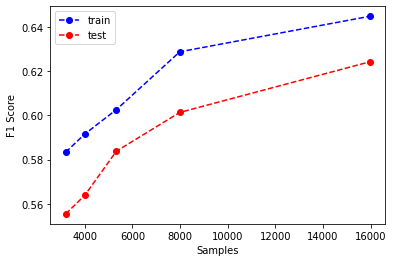

In [25]:
plt.plot(scores['Sample Size'], scores['F1 Score Train'], 'ob--', label='train')
plt.plot(scores['Sample Size'], scores['F1 Score Test'], 'or--', label='test')
plt.legend()
plt.xlabel('Samples')
plt.ylabel('F1 Score')

### Learning curve for Linear Regression model with Count Vectorizer

Text(0, 0.5, 'F1 Score')

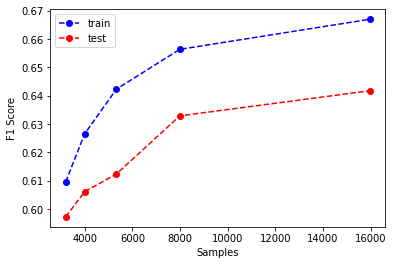

In [24]:
plt.plot(scores['Sample Size'], scores['F1 Score Train CV'], 'ob--', label='train')
plt.plot(scores['Sample Size'], scores['F1 Score Test CV'], 'or--', label='test')
plt.legend()
plt.xlabel('Samples')
plt.ylabel('F1 Score')

Train Set Classification report for Logistic Regression model with TF-IDF Vectorizer

In [26]:
print(classification_report(df_train['label'], Y_train_predict))

              precision    recall  f1-score   support

           0       0.46      0.56      0.51      7458
           1       0.12      0.00      0.01      2073
           2       0.40      0.42      0.41      6445

    accuracy                           0.43     15976
   macro avg       0.33      0.33      0.31     15976
weighted avg       0.39      0.43      0.40     15976



Test Set Classification report for Logistic Regression model with TF-IDF Vectorizer

In [27]:
print(classification_report(df_test['label'], Y_test_predict))

              precision    recall  f1-score   support

           0       0.72      0.80      0.76      1065
           1       0.64      0.02      0.05       296
           2       0.60      0.72      0.66       921

    accuracy                           0.66      2282
   macro avg       0.65      0.51      0.49      2282
weighted avg       0.66      0.66      0.62      2282



Train Set Classification report for Logistic Regression model with Count Vectorizer

In [28]:
print(classification_report(df_train['label'], Y_train_predict_cv))

              precision    recall  f1-score   support

           0       0.47      0.51      0.49      7458
           1       0.11      0.01      0.03      2073
           2       0.40      0.47      0.43      6445

    accuracy                           0.43     15976
   macro avg       0.33      0.33      0.32     15976
weighted avg       0.40      0.43      0.41     15976



Test Set Classification report for Logistic Regression with Count Vectorizer 

In [29]:
print(classification_report(df_test['label'], Y_test_predict_cv))

              precision    recall  f1-score   support

           0       0.74      0.80      0.76      1065
           1       0.68      0.07      0.13       296
           2       0.61      0.73      0.66       921

    accuracy                           0.67      2282
   macro avg       0.67      0.53      0.52      2282
weighted avg       0.68      0.67      0.64      2282

